# Before-Augmentation Baseline Fault Classification

This notebook trains the follwoing models on the 20260707-20260710 data before applying data augmentation:

- Random Forest
- Gradient Boosting
- SVM
- LSTM-AE

Data range:

20260707-20260710

Goal: classify `Alarm_Code` using the available PLC process signals before augmentation.

In [ ]:
import sys
print(sys.executable)

d:\CODE\Weaving_Project\.weaving_tf\Scripts\python.exe


## 1. Imports

In [3]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE_DIR = Path.cwd()
DATA_PATH = "/content/drive/MyDrive/LSTM_AE_Weaving/full_time_gap_report_clean.csv"
OUTPUT_DIR = Path("/content/drive/MyDrive/LSTM_AE_Weaving/baseline_models_before_augmentation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Main split: train on July 8 and July 9, test on July 10.
TRAIN_DATES = ["2026-07-08", "2026-07-09"]
TEST_DATE = "2026-07-10"

# Use None to train RF/GB on all July 8-9 training rows. Use an integer for a stratified training sample.
MAX_TRAIN_ROWS_FOR_RF_GB = None

# Use all July 8-9 training rows for SVM by default.
# If RBF/kernel SVM is too slow, uncomment the next line and choose a practical cap, e.g. 50_000.
SVM_MAX_TRAIN_ROWS = None
# SVM_MAX_TRAIN_ROWS = 50_000

N_SPLITS_CV = 5

print(DATA_PATH)
print(OUTPUT_DIR)

/content/drive/MyDrive/LSTM_AE_Weaving/full_time_gap_report_clean.csv
/content/drive/MyDrive/LSTM_AE_Weaving/baseline_models_before_augmentation


## 3. Load Dataset

In [6]:
df = pd.read_csv(DATA_PATH)
df["logged_at"] = pd.to_datetime(df["logged_at"], errors="coerce", format="mixed")

if df["logged_at"].isna().any():
    bad_rows = int(df["logged_at"].isna().sum())
    raise ValueError(f"{bad_rows} logged_at values could not be parsed as datetimes.")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Date range: {df['logged_at'].min()} to {df['logged_at'].max()}")
display(df.head())
display(df.dtypes.to_frame("dtype").head(40))


Rows: 2,565,389
Columns: 37
Date range: 2026-07-08 00:00:00.080000 to 2026-07-10 23:59:59.902000


,dataset_id,excel_row_number,logged_at,previous_logged_at,time_gap_seconds,previous_dataset_id,previous_excel_row_number,Infeed_Speed_SV,Infeed_Speed_PV,INFEED_TORQUE,...,Single_Speed_SV,SINGLE_LIMIT_TRQ,Weaving_Run,Alarm_Code,Temperature_PV,Humidity_PV,tag27,tag28,tag29,tag30
0,1,2,2026-07-08 00:00:00.080,NaN,NaN,NaN,NaN,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
1,2,3,2026-07-08 00:00:00.182,2026-07-08 00:00:00.080,0.102,1.0,2.0,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
2,3,4,2026-07-08 00:00:00.284,2026-07-08 00:00:00.182,0.102,2.0,3.0,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
3,4,5,2026-07-08 00:00:00.389,2026-07-08 00:00:00.284,0.105,3.0,4.0,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
4,5,6,2026-07-08 00:00:00.488,2026-07-08 00:00:00.389,0.099,4.0,5.0,0.19,0.19,2.5,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN


,dtype
dataset_id,int64
excel_row_number,int64
logged_at,datetime64[ns]
previous_logged_at,object
time_gap_seconds,float64
previous_dataset_id,float64
previous_excel_row_number,float64
Infeed_Speed_SV,float64
Infeed_Speed_PV,float64
INFEED_TORQUE,float64


## 4. Inspect Target Distribution

,rows,percent
Alarm_Code,,
0,2000751,77.990
2,99674,3.885
8,459558,17.914
10,5406,0.211


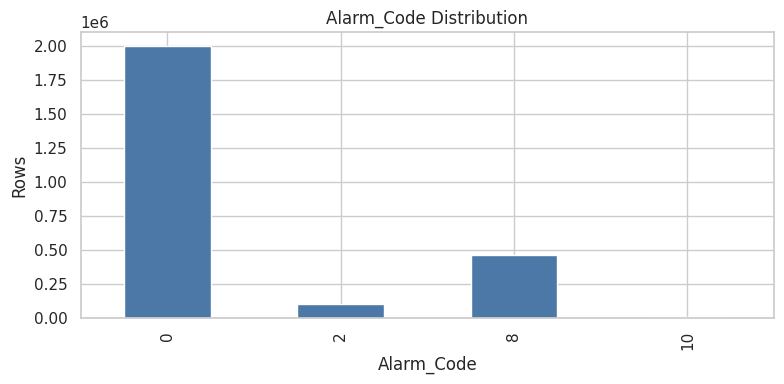

In [7]:
TARGET = "Alarm_Code"

target_counts = df[TARGET].value_counts(dropna=False).sort_index()
target_percent = (target_counts / len(df) * 100).round(3)
target_summary = pd.DataFrame({"rows": target_counts, "percent": target_percent})

display(target_summary)

ax = target_counts.plot(kind="bar", figsize=(8, 4), color="#4c78a8")
ax.set_title("Alarm_Code Distribution")
ax.set_xlabel("Alarm_Code")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

## 5. Preprocessing: Remove Empty Columns, Constant Features, and Non-Signal Metadata

We remove:

- completely empty columns
- columns with only one unique non-empty value
- metadata/time/index columns that should not be used as sensor features
- previous-row helper columns such as `previous_logged_at`, `time_gap_seconds`, `previous_dataset_id`, and `previous_excel_row_number`
- `Alarm_Code` from features because it is the target

This keeps the model focused on PLC process signals rather than row identity, timestamps, or logging-gap artifacts.


In [8]:
metadata_cols = {
    "dataset_id",
    "excel_row_number",
    "logged_at",
    "previous_logged_at",
    "time_gap_seconds",
    "previous_dataset_id",
    "previous_excel_row_number",
    TARGET,
}

empty_cols = [col for col in df.columns if df[col].isna().all()]

candidate_cols = [col for col in df.columns if col not in metadata_cols and col not in empty_cols]

# Convert candidates to numeric where possible. Non-numeric columns become all NaN and will be removed.
X_all = df[candidate_cols].apply(pd.to_numeric, errors="coerce")

all_nan_after_numeric = [col for col in X_all.columns if X_all[col].isna().all()]
X_all = X_all.drop(columns=all_nan_after_numeric)

constant_cols = [col for col in X_all.columns if X_all[col].nunique(dropna=True) <= 1]
X_all = X_all.drop(columns=constant_cols)

y_all = pd.to_numeric(df[TARGET], errors="coerce").fillna(0).astype(int)

preprocess_report = {
    "original_rows": int(len(df)),
    "original_columns": int(df.shape[1]),
    "removed_metadata_columns": sorted([c for c in metadata_cols if c in df.columns]),
    "removed_empty_columns": empty_cols,
    "removed_non_numeric_columns": all_nan_after_numeric,
    "removed_constant_columns": constant_cols,
    "final_feature_count": int(X_all.shape[1]),
    "final_features": list(X_all.columns),
}

with open(OUTPUT_DIR / "preprocess_report_before_augmentation.json", "w", encoding="utf-8") as f:
    json.dump(preprocess_report, f, indent=2)

print(f"Final feature count: {X_all.shape[1]}")
print("Final features:")
for col in X_all.columns:
    print("-", col)

print("Removed metadata/helper columns:", sorted([c for c in metadata_cols if c in df.columns]))
print("Removed empty columns:", empty_cols)
print("Removed constant columns:", constant_cols)


Final feature count: 12
Final features:
- Infeed_Speed_SV
- Infeed_Speed_PV
- INFEED_TORQUE
- Loadcell_Weight_PV
- Dancer_Pressure_PV
- Dancer_Gyro_Position
- Weaving_Line_Speed
- Loadcell_PV
- Motor_RPM
- Weaving_Run
- Temperature_PV
- Humidity_PV
Removed metadata/helper columns: ['Alarm_Code', 'dataset_id', 'excel_row_number', 'logged_at', 'previous_dataset_id', 'previous_excel_row_number', 'previous_logged_at', 'time_gap_seconds']
Removed empty columns: ['tag27', 'tag28', 'tag29', 'tag30']
Removed constant columns: ['Loadcell_Weight_SV', 'Dancer_Pressure_SV', 'Dancer_Weight_SV', 'PID_P', 'PID_I', 'PID_D', 'PID_Limit', 'Speed_Limit', 'Infeed_Input_Scale', 'Loadcell_Deadzone', 'Loadcell_Allowtime', 'Single_Speed_SV', 'SINGLE_LIMIT_TRQ']


## 6. Optional Stratified Sampling for Training Only

The main evaluation is date/time-based:

- Train: July 8 and July 9
- Test: July 10

If the training set is too large, `MAX_TRAIN_ROWS_FOR_RF_GB` can reduce only the training rows using stratified sampling. The July 10 test set is not sampled by default, so it remains a future-date holdout.


In [9]:
def stratified_sample(X, y, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(X) <= max_rows:
        return X.reset_index(drop=True), y.reset_index(drop=True)

    sample_frac = max_rows / len(X)
    sample_idx = (
        pd.DataFrame({"target": y})
        .groupby("target", group_keys=False)
        .apply(lambda g: g.sample(max(1, int(round(len(g) * sample_frac))), random_state=random_state))
        .index
    )
    return X.loc[sample_idx].reset_index(drop=True), y.loc[sample_idx].reset_index(drop=True)


def make_date_split():
    """Create the July 8-9 train / July 10 test split whenever needed."""
    required = ["df", "X_all", "y_all", "TRAIN_DATES", "TEST_DATE"]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Missing required variables: " + ", ".join(missing) +
            ". Run the load and preprocessing cells first."
        )

    df["logged_at"] = pd.to_datetime(df["logged_at"], errors="coerce", format="mixed")
    if df["logged_at"].isna().any():
        bad_rows = int(df["logged_at"].isna().sum())
        raise ValueError(f"{bad_rows} logged_at values could not be parsed as datetimes.")

    row_dates = df["logged_at"].dt.strftime("%Y-%m-%d")
    train_mask = row_dates.isin(TRAIN_DATES)
    test_mask = row_dates.eq(TEST_DATE)

    if not train_mask.any():
        raise ValueError(f"No training rows found for TRAIN_DATES={TRAIN_DATES}")
    if not test_mask.any():
        raise ValueError(f"No test rows found for TEST_DATE={TEST_DATE}")

    X_train_full_local = X_all.loc[train_mask].reset_index(drop=True)
    y_train_full_local = y_all.loc[train_mask].reset_index(drop=True)
    X_test_local = X_all.loc[test_mask].reset_index(drop=True)
    y_test_local = y_all.loc[test_mask].reset_index(drop=True)
    X_train_local, y_train_local = stratified_sample(
        X_train_full_local, y_train_full_local, MAX_TRAIN_ROWS_FOR_RF_GB
    )

    return X_train_full_local, y_train_full_local, X_train_local, y_train_local, X_test_local, y_test_local


def ensure_date_split():
    """Populate split variables if they do not already exist."""
    global X_train_full, y_train_full, X_train, y_train, X_test, y_test
    if all(name in globals() for name in ["X_train_full", "y_train_full", "X_train", "y_train", "X_test", "y_test"]):
        return
    print("Date split variables were not found. Creating July 8-9 train / July 10 test split...")
    X_train_full, y_train_full, X_train, y_train, X_test, y_test = make_date_split()


## 17. LSTM Autoencoder Baseline Before Augmentation

The paper also uses an LSTM Autoencoder for anomaly detection. This is different from RF/GB/SVM classification:

- RF/GB/SVM predict `Alarm_Code` classes directly.
- LSTM-AE learns to reconstruct normal sequences.
- A sequence is flagged as anomalous when reconstruction error exceeds a threshold.

Architecture used from the paper:

- Input: `(seq_length, n_features)`
- LSTM Encoder: `128` units, ReLU, returns sequence
- RepeatVector: repeats latent representation across sequence length
- LSTM Decoder: `128` units, ReLU, returns sequence
- Dense: `n_features`

Training setup here:

- Train on normal sequences from July 8-9 only (`Alarm_Code = 0`).
- Test on July 10 sequences.
- Sequence label is binary: `0 = all rows normal`, `1 = one or more alarm rows in the sequence`.
- Threshold is the 95th percentile of training reconstruction error


In [10]:
# LSTM-AE configuration
LSTM_SEQUENCE_LENGTH = 100
LSTM_SEQUENCE_STEP = 10
LSTM_MAX_NORMAL_TRAIN_SEQUENCES = 20_000
LSTM_MAX_TEST_SEQUENCES = 50_000
LSTM_EPOCHS = 10
LSTM_BATCH_SIZE = 256
LSTM_THRESHOLD_PERCENTILE = 95

print("LSTM sequence length:", LSTM_SEQUENCE_LENGTH)
print("LSTM sequence step:", LSTM_SEQUENCE_STEP)
print("Max normal train sequences:", LSTM_MAX_NORMAL_TRAIN_SEQUENCES)
print("Max test sequences:", LSTM_MAX_TEST_SEQUENCES)


LSTM sequence length: 100
LSTM sequence step: 10
Max normal train sequences: 20000
Max test sequences: 50000


In [11]:
try:
    import tensorflow as tf
    from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
    from tensorflow.keras.models import Model
    from tensorflow.keras.callbacks import EarlyStopping
    from sklearn.preprocessing import MinMaxScaler
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for the LSTM-AE section. "
        "Install it in the .weaving environment before running this section."
    ) from exc

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


TensorFlow version: 2.20.0


In [12]:
ensure_date_split()

# Fit scaler on July 8-9 training rows only to avoid test-day leakage.
scaler = MinMaxScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

y_train_binary_full = (y_train_full != 0).astype(int).to_numpy()
y_test_binary = (y_test != 0).astype(int).to_numpy()

print("Training rows for sequence source:", X_train_scaled_full.shape)
print("Test rows for sequence source:", X_test_scaled.shape)
print("Feature count:", X_train_scaled_full.shape[1])


Date split variables were not found. Creating July 8-9 train / July 10 test split...
Training rows for sequence source: (1710166, 12)
Test rows for sequence source: (855223, 12)
Feature count: 12


In [13]:
def make_sequences(X, y_binary, seq_length, step):
    """Create fixed-length sequences and binary labels from continuous time-ordered rows."""
    X = np.asarray(X, dtype=np.float32)
    y_binary = np.asarray(y_binary, dtype=np.int8)
    if len(X) < seq_length:
        return np.empty((0, seq_length, X.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.int8), np.empty((0,), dtype=int)

    sequences = []
    labels = []
    start_indices = []
    for start in range(0, len(X) - seq_length + 1, step):
        end = start + seq_length
        sequences.append(X[start:end])
        labels.append(int(y_binary[start:end].max()))
        start_indices.append(start)

    return np.stack(sequences), np.asarray(labels, dtype=np.int8), np.asarray(start_indices, dtype=int)

X_train_seq_all, y_train_seq_all, train_start_idx = make_sequences(
    X_train_scaled_full,
    y_train_binary_full,
    LSTM_SEQUENCE_LENGTH,
    LSTM_SEQUENCE_STEP,
)
X_test_seq, y_test_seq, test_start_idx = make_sequences(
    X_test_scaled,
    y_test_binary,
    LSTM_SEQUENCE_LENGTH,
    LSTM_SEQUENCE_STEP,
)

# Autoencoder trains only on fully normal sequences from July 8-9.
normal_train_mask = y_train_seq_all == 0
X_lstm_train = X_train_seq_all[normal_train_mask]

if len(X_lstm_train) > LSTM_MAX_NORMAL_TRAIN_SEQUENCES:
    rng = np.random.default_rng(RANDOM_STATE)
    selected = rng.choice(len(X_lstm_train), size=LSTM_MAX_NORMAL_TRAIN_SEQUENCES, replace=False)
    X_lstm_train = X_lstm_train[selected]

if len(X_test_seq) > LSTM_MAX_TEST_SEQUENCES:
    rng = np.random.default_rng(RANDOM_STATE)
    selected = np.sort(rng.choice(len(X_test_seq), size=LSTM_MAX_TEST_SEQUENCES, replace=False))
    X_test_seq_eval = X_test_seq[selected]
    y_test_seq_eval = y_test_seq[selected]
    test_start_idx_eval = test_start_idx[selected]
else:
    X_test_seq_eval = X_test_seq
    y_test_seq_eval = y_test_seq
    test_start_idx_eval = test_start_idx

print(f"All train sequences: {len(X_train_seq_all):,}")
print(f"Normal train sequences used by LSTM-AE: {len(X_lstm_train):,}")
print(f"All test sequences: {len(X_test_seq):,}")
print(f"Test sequences evaluated: {len(X_test_seq_eval):,}")
print("Test sequence label distribution:")
display(pd.Series(y_test_seq_eval).value_counts().sort_index().rename(index={0:"normal", 1:"alarm"}).to_frame("sequences"))


All train sequences: 171,007
Normal train sequences used by LSTM-AE: 20,000
All test sequences: 85,513
Test sequences evaluated: 50,000
Test sequence label distribution:


,sequences
normal,38922
alarm,11078


In [14]:
seq_length = LSTM_SEQUENCE_LENGTH
n_features = X_lstm_train.shape[2]

inputs = Input(shape=(seq_length, n_features))
encoded_sequence = LSTM(128, activation="relu", return_sequences=True)(inputs)
encoded_vector = LSTM(128, activation="relu", return_sequences=False)(encoded_sequence)
repeated = RepeatVector(seq_length)(encoded_vector)
decoded = LSTM(128, activation="relu", return_sequences=True)(repeated)
outputs = TimeDistributed(Dense(n_features))(decoded)

lstm_ae = Model(inputs, outputs, name="lstm_autoencoder_before_augmentation")
lstm_ae.compile(optimizer="adam", loss="mse")
lstm_ae.summary()


Model: "lstm_autoencoder_before_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 12)        │         1,548 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,908 (1.29 MB)

 Trainable params: 336,908 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - loss: 0.0426 - val_loss: 0.0106
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - loss: 0.0066 - val_loss: 0.0047
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - loss: 0.0041 - val_loss: 0.0038
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - loss: 0.0037 - val_loss: 0.0038
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - loss: 0.0110 - val_loss: 0.0052
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - loss: 0.0042 - val_loss: 0.0036
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - loss: 0.0038 - val_loss: 0.0036
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - loss: 0.0035 - val_loss: 0.0036
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - loss: 0.0034 - val_loss: 0.0033
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - loss: 0.0032 - val_loss: 0.0031


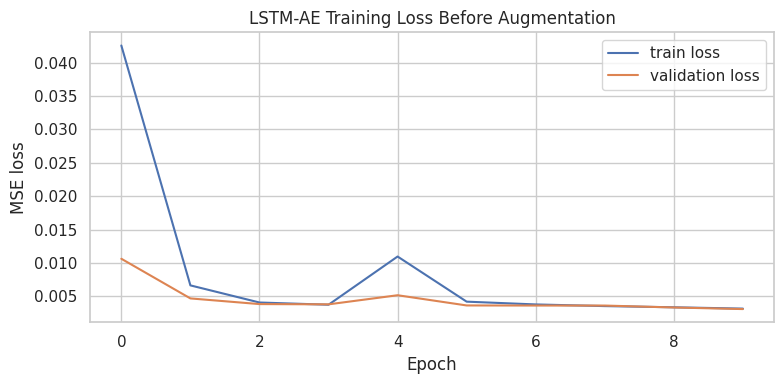

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = lstm_ae.fit(
    X_lstm_train,
    X_lstm_train,
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("LSTM-AE Training Loss Before Augmentation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()


Reconstruction threshold (95th percentile): 0.00448558
LSTM-AE binary anomaly metrics on July 10 sequences:
Accuracy: 0.72754
Precision: 0.3676547061882475
Recall: 0.3191009207438166
F1: 0.34166143140192334
Classification report:
              precision    recall  f1-score   support

      normal       0.81      0.84      0.83     38922
       alarm       0.37      0.32      0.34     11078

    accuracy                           0.73     50000
   macro avg       0.59      0.58      0.58     50000
weighted avg       0.71      0.73      0.72     50000



,pred_normal,pred_alarm
actual_normal,32842,6080
actual_alarm,7543,3535


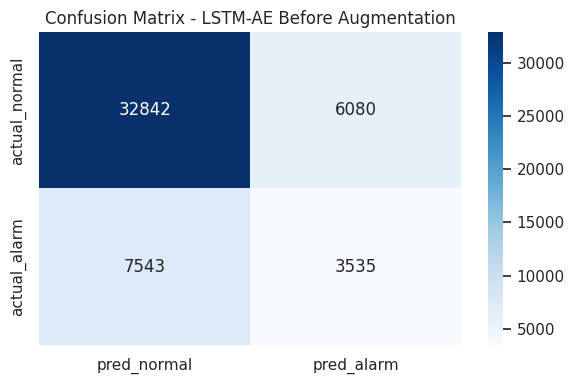

In [16]:
def reconstruction_error(model, X_seq, batch_size=LSTM_BATCH_SIZE):
    reconstructed = model.predict(X_seq, batch_size=batch_size, verbose=0)
    return np.mean(np.square(X_seq - reconstructed), axis=(1, 2))

train_errors = reconstruction_error(lstm_ae, X_lstm_train)
threshold = np.percentile(train_errors, LSTM_THRESHOLD_PERCENTILE)

test_errors = reconstruction_error(lstm_ae, X_test_seq_eval)
y_lstm_pred = (test_errors > threshold).astype(int)

print(f"Reconstruction threshold ({LSTM_THRESHOLD_PERCENTILE}th percentile): {threshold:.8f}")
print("LSTM-AE binary anomaly metrics on July 10 sequences:")
print("Accuracy:", accuracy_score(y_test_seq_eval, y_lstm_pred))
print("Precision:", precision_score(y_test_seq_eval, y_lstm_pred, zero_division=0))
print("Recall:", recall_score(y_test_seq_eval, y_lstm_pred, zero_division=0))
print("F1:", f1_score(y_test_seq_eval, y_lstm_pred, zero_division=0))
print("Classification report:")
print(classification_report(y_test_seq_eval, y_lstm_pred, target_names=["normal", "alarm"], zero_division=0))

lstm_cm = confusion_matrix(y_test_seq_eval, y_lstm_pred, labels=[0, 1])
lstm_cm_df = pd.DataFrame(lstm_cm, index=["actual_normal", "actual_alarm"], columns=["pred_normal", "pred_alarm"])
display(lstm_cm_df)

plt.figure(figsize=(6, 4))
sns.heatmap(lstm_cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - LSTM-AE Before Augmentation")
plt.tight_layout()
plt.show()


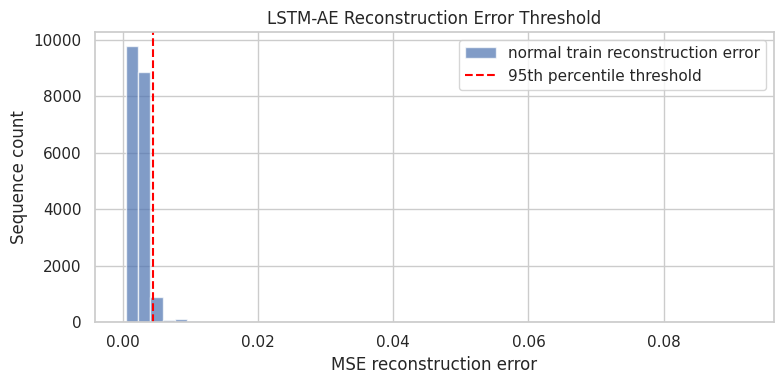

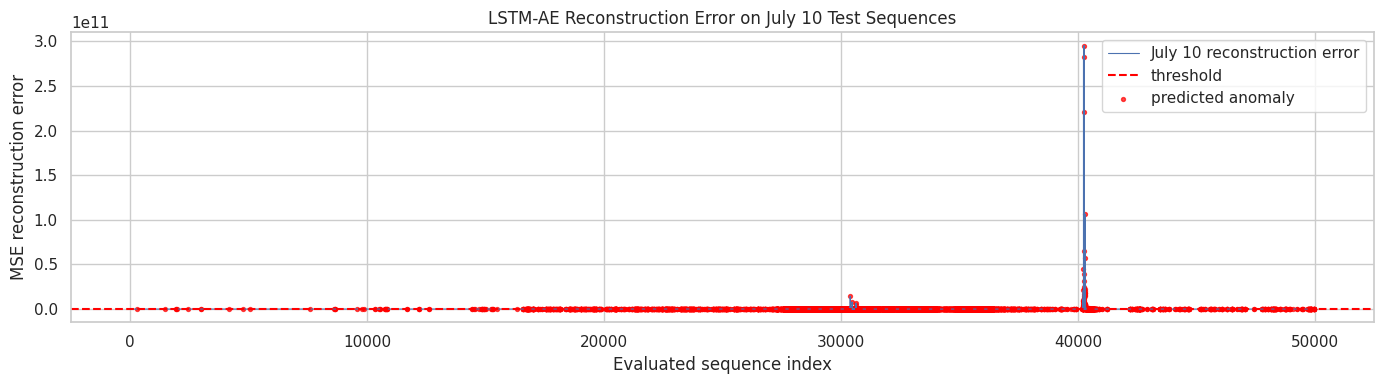

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(train_errors, bins=50, alpha=0.7, label="normal train reconstruction error")
plt.axvline(threshold, color="red", linestyle="--", label=f"{LSTM_THRESHOLD_PERCENTILE}th percentile threshold")
plt.title("LSTM-AE Reconstruction Error Threshold")
plt.xlabel("MSE reconstruction error")
plt.ylabel("Sequence count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(test_errors, linewidth=0.8, label="July 10 reconstruction error")
plt.axhline(threshold, color="red", linestyle="--", label="threshold")
plt.scatter(
    np.where(y_lstm_pred == 1)[0],
    test_errors[y_lstm_pred == 1],
    s=8,
    color="red",
    label="predicted anomaly",
    alpha=0.7,
)
plt.title("LSTM-AE Reconstruction Error on July 10 Test Sequences")
plt.xlabel("Evaluated sequence index")
plt.ylabel("MSE reconstruction error")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
lstm_metrics = {
    "model": "LSTM Autoencoder",
    "task": "binary anomaly detection",
    "train_dates": ",".join(TRAIN_DATES),
    "test_date": TEST_DATE,
    "sequence_length": LSTM_SEQUENCE_LENGTH,
    "sequence_step": LSTM_SEQUENCE_STEP,
    "normal_train_sequences": int(len(X_lstm_train)),
    "test_sequences": int(len(X_test_seq_eval)),
    "threshold_percentile": LSTM_THRESHOLD_PERCENTILE,
    "threshold": float(threshold),
    "accuracy": accuracy_score(y_test_seq_eval, y_lstm_pred),
    "precision": precision_score(y_test_seq_eval, y_lstm_pred, zero_division=0),
    "recall": recall_score(y_test_seq_eval, y_lstm_pred, zero_division=0),
    "f1": f1_score(y_test_seq_eval, y_lstm_pred, zero_division=0),
}

lstm_metrics_df = pd.DataFrame([lstm_metrics])
display(lstm_metrics_df)
lstm_metrics_df.to_csv(OUTPUT_DIR / "lstm_autoencoder_metrics_before_augmentation.csv", index=False)
lstm_cm_df.to_csv(OUTPUT_DIR / "confusion_matrix_lstm_autoencoder_before_augmentation.csv")

error_df = pd.DataFrame({
    "test_sequence_start_index": test_start_idx_eval,
    "true_binary_alarm_sequence": y_test_seq_eval,
    "reconstruction_error": test_errors,
    "predicted_anomaly": y_lstm_pred,
})
error_df.to_csv(OUTPUT_DIR / "lstm_autoencoder_reconstruction_errors_before_augmentation.csv", index=False)


,model,task,train_dates,test_date,sequence_length,sequence_step,normal_train_sequences,test_sequences,threshold_percentile,threshold,accuracy,precision,recall,f1
0,LSTM Autoencoder,binary anomaly detection,"2026-07-08,2026-07-09",2026-07-10,100,10,20000,50000,95,0.004486,0.72754,0.367655,0.319101,0.341661


## 18. Notes for the Next Step: Augmentation

After this baseline is complete, the next notebook should create augmented training windows only from the July 8-9 training set, then retrain the same models and evaluate on the unchanged July 10 test set.

Important: augmentation should not be applied before the date split, because that would leak synthetic versions of future test-day behavior into training.
